# Comparing a stitched `glo_30` with the NISAR DEM

The [NISAR DEM v1.2](https://nisar-docs.asf.alaska.edu/nisar-dem/) is the Copernicus GLO-30 (2023_1) re-referenced to the WGS84 ellipsoid by JPL (EGM2008 removed at the source). It therefore serves as an independent reference for the stitcher geoid handling: stitching `glo_30` with `dst_ellipsoidal_height=True` and `dst_area_or_point='Point'` should reproduce the NISAR DEM on the native Copernicus lattice.

Prior to the fix of [issue #151](https://github.com/ACCESS-Cloud-Based-InSAR/dem-stitcher/issues/151), the 'Point' path shifted the geoid by half a *geoid* pixel (~30 arcseconds) rather than half a *DEM* pixel, biasing ellipsoidal heights by up to several centimeters wherever the geoid has a gradient.

Copernicus coarsens the longitudinal posting of GLO-30 in latitude bands (1 arcsecond below 50 degrees, then 1.5, 2, 3, 5 and 10 arcseconds at 50, 60, 70, 80 and 85 degrees) while the latitudinal posting stays at 1 arcsecond. The half-*DEM*-pixel shift is therefore anisotropic and grows with latitude, so we compare at Los Angeles (1 arcsecond) and at Anchorage, Alaska (2 arcseconds).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dem_stitcher import stitch_dem

Global variables defining the comparison.

In [2]:
SITES = {
    'Los Angeles': [-118.8, 34.6, -118.5, 34.8],
    'Anchorage': [-150.0, 61.15, -149.9, 61.25],
}
DST_AREA_OR_POINT = 'Point'
CMAP = 'RdBu_r'
DIFF_LIM_M = 0.01

The `almost_equals` check rather than strict equality: the 1.5 and 3 arcsecond postings are stored as floats that differ by a single ULP between the Copernicus and NISAR tile headers, so the grids coincide but the transforms are not bit-identical in every band.

In [3]:
def compare_with_nisar(bounds: list[float]) -> tuple[np.ndarray, np.ndarray, dict]:
    X_nisar, p_nisar = stitch_dem(bounds, 'nisar_dem', dst_area_or_point=DST_AREA_OR_POINT)
    X_glo, p_glo = stitch_dem(bounds, 'glo_30', dst_ellipsoidal_height=True, dst_area_or_point=DST_AREA_OR_POINT)
    assert p_nisar['transform'].almost_equals(p_glo['transform'])
    return X_nisar, X_glo, p_glo

In [4]:
comparisons = {name: compare_with_nisar(bounds) for name, bounds in SITES.items()}

Opening nisar_dem Datasets:   0%|          | 0/1 [00:00<?, ?it/s]

Opening nisar_dem Datasets: 100%|██████████| 1/1 [00:02<00:00,  2.02s/it]

Opening nisar_dem Datasets: 100%|██████████| 1/1 [00:02<00:00,  2.02s/it]

Reading tile metadata:   0%|          | 0/1 [00:00<?, ?it/s]

Reading tile metadata: 100%|██████████| 1/1 [00:00<00:00, 303.32it/s]

...

Reading tile metadata:   0%|          | 0/1 [00:00<?, ?it/s]

Reading tile metadata: 100%|██████████| 1/1 [00:00<00:00, 1027.76it/s]

Reading tile imagery:   0%|          | 0/1 [00:00<?, ?it/s]

Reading tile imagery: 100%|██████████| 1/1 [00:01<00:00,  1.87s/it]

Reading tile imagery: 100%|██████████| 1/1 [00:01<00:00,  1.88s/it]

The grids align exactly at both sites. The remaining difference is the EGM2008 model/resolution difference between the geoid grid used by JPL and the 1 arcminute agisoft EGM2008 grid used here (plus `float32` rounding and any Copernicus 2021 vs 2023_1 tile updates).

In [5]:
stats = pd.DataFrame(
    [
        {
            'site': name,
            'lat': (SITES[name][1] + SITES[name][3]) / 2,
            'res_x_arcsec': p['transform'].a * 3600,
            'res_y_arcsec': -p['transform'].e * 3600,
            'mean_m': float(np.nanmean(X_nisar - X_glo)),
            'std_m': float(np.nanstd(X_nisar - X_glo)),
            'max_abs_m': float(np.nanmax(np.abs(X_nisar - X_glo))),
        }
        for name, (X_nisar, X_glo, p) in comparisons.items()
    ]
).set_index('site')
stats

,lat,res_x_arcsec,res_y_arcsec,mean_m,std_m,max_abs_m
site,,,,,,
Los Angeles,34.7,1.0,1.0,-0.000239,0.001136,0.002930
Anchorage,61.2,2.0,1.0,-0.000265,0.000157,0.000678


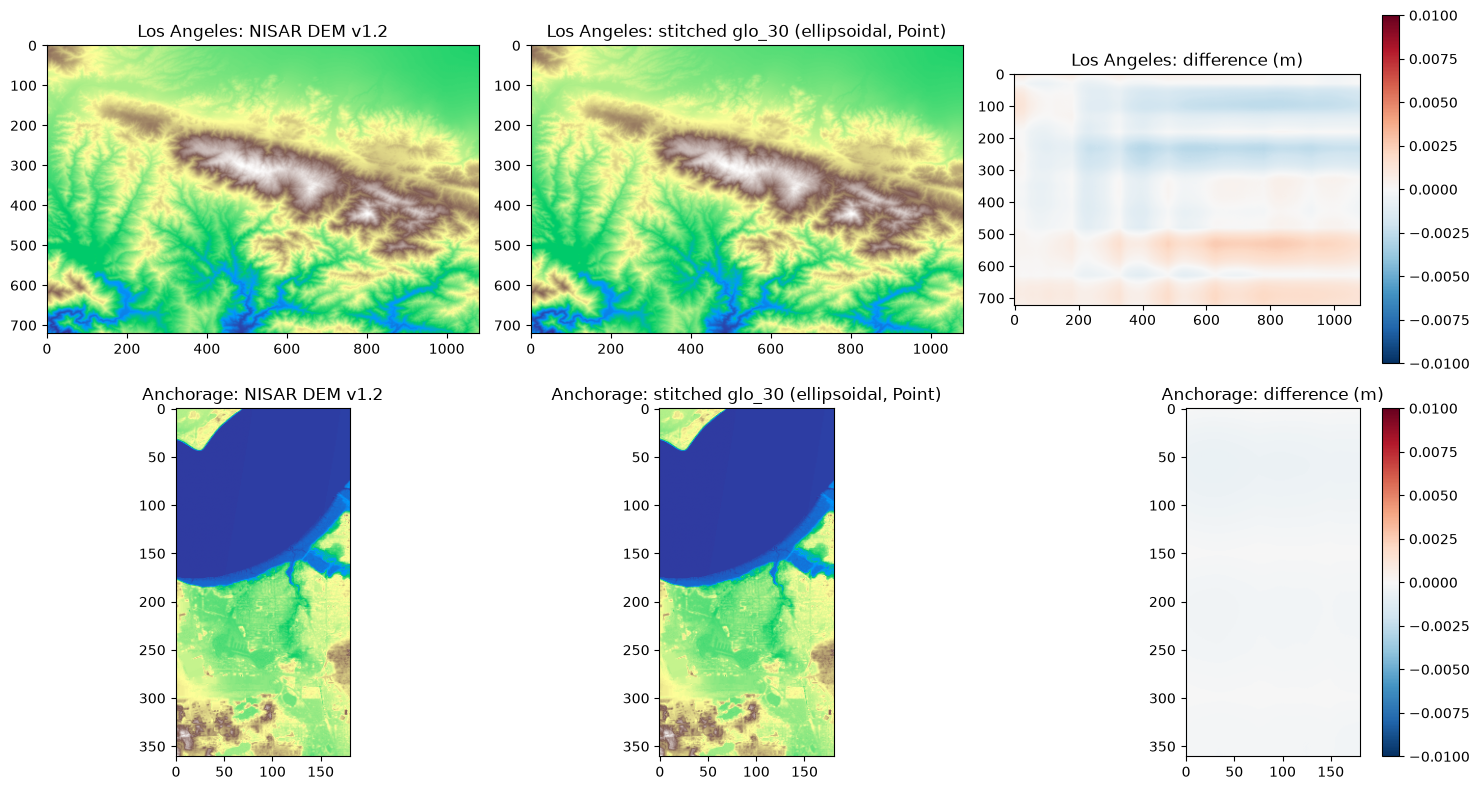

In [6]:
fig, axes = plt.subplots(len(comparisons), 3, figsize=(15, 4 * len(comparisons)))
for row, (name, (X_nisar, X_glo, _)) in zip(axes, comparisons.items()):
    row[0].imshow(X_nisar, cmap='terrain')
    row[0].set_title(f'{name}: NISAR DEM v1.2')
    row[1].imshow(X_glo, cmap='terrain')
    row[1].set_title(f'{name}: stitched glo_30 (ellipsoidal, Point)')
    im = row[2].imshow(X_nisar - X_glo, cmap=CMAP, vmin=-DIFF_LIM_M, vmax=DIFF_LIM_M)
    row[2].set_title(f'{name}: difference (m)')
    fig.colorbar(im, ax=row[2])
plt.tight_layout()

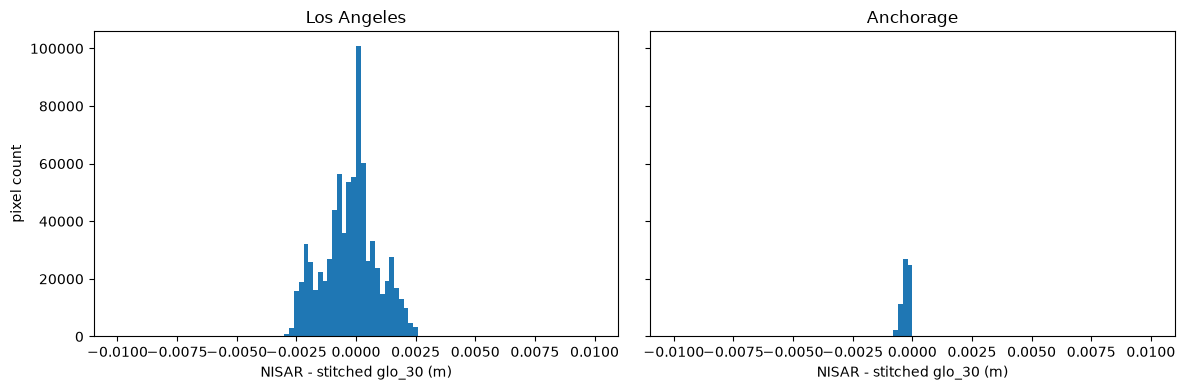

In [7]:
fig, axes = plt.subplots(1, len(comparisons), figsize=(6 * len(comparisons), 4), sharey=True)
for ax, (name, (X_nisar, X_glo, _)) in zip(axes, comparisons.items()):
    ax.hist((X_nisar - X_glo).ravel(), bins=100, range=(-DIFF_LIM_M, DIFF_LIM_M))
    ax.set_title(name)
    ax.set_xlabel('NISAR - stitched glo_30 (m)')
axes[0].set_ylabel('pixel count')
plt.tight_layout()

Both sites agree at the millimeter level, and the Anchorage residual is if anything smaller than the Los Angeles one even though its longitudinal pixel is twice as wide. That is the behavior we want: the geoid is shifted by half a *DEM* pixel, so the shift tracks the 2 arcsecond posting instead of assuming 1 arcsecond. With the pre-#151 half-*geoid*-pixel shift the error scales with the mismatch between the geoid posting and the DEM posting, so the high latitude bands - where the posting is anisotropic - are exactly where it degrades fastest.